In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", context="talk")


### Import Paths

In [13]:
BASE_DIR = Path("..").resolve()
RESULTS_DIR = BASE_DIR / "results"

RESULTS_DIR, RESULTS_DIR.exists()

(WindowsPath('C:/Users/mkcak/OneDrive - Hochschule Luzern/Modules/master_thesis/multimodal-finance-forecasting/code/results'),
 True)

In [14]:
metric_files = glob.glob(str(RESULTS_DIR / "**/overall_metrics_*.csv"), recursive=True)
metric_files


['C:\\Users\\mkcak\\OneDrive - Hochschule Luzern\\Modules\\master_thesis\\multimodal-finance-forecasting\\code\\results\\overall_metrics_all_models.csv',
 'C:\\Users\\mkcak\\OneDrive - Hochschule Luzern\\Modules\\master_thesis\\multimodal-finance-forecasting\\code\\results\\overall_metrics_summary.csv',
 'C:\\Users\\mkcak\\OneDrive - Hochschule Luzern\\Modules\\master_thesis\\multimodal-finance-forecasting\\code\\results\\linear_ar\\overall_metrics_linear.csv',
 'C:\\Users\\mkcak\\OneDrive - Hochschule Luzern\\Modules\\master_thesis\\multimodal-finance-forecasting\\code\\results\\lstm\\overall_metrics_lstm.csv',
 'C:\\Users\\mkcak\\OneDrive - Hochschule Luzern\\Modules\\master_thesis\\multimodal-finance-forecasting\\code\\results\\xgboost\\overall_metrics_xgb.csv']

### Load & standardise per-model metrics

In [15]:
# Explicit mapping from model family to its metrics file
metric_files = {
    "Linear AR": RESULTS_DIR / "linear_ar" / "overall_metrics_linear.csv",
    "LSTM":      RESULTS_DIR / "lstm"      / "overall_metrics_lstm.csv",
    "XGBoost":   RESULTS_DIR / "xgboost"   / "overall_metrics_xgb.csv",
}

frames = []

for family, path in metric_files.items():
    df = pd.read_csv(path)

    # --- harmonise columns for LSTM if needed ---
    if "Model" in df.columns and "model_id" not in df.columns:
        df["model_id"] = (
            df["Model"]
            .str.lower()
            .str.replace(" ", "_")
            .str.replace("+", "plus")
            .str.replace("__", "_")
        )
        df.drop(columns=["Model"], inplace=True)

    # infer baseline vs multimodal if 'type' missing
    if "type" not in df.columns:
        df["type"] = df["model_id"].apply(
            lambda x: "baseline" if "baseline" in x or "base" in x else "multimodal"
        )

    df["family"] = family
    frames.append(df)

# Concatenate all models into one clean table
results = pd.concat(frames, ignore_index=True)

# Keep only columns we really need
keep_cols = ["family", "model_id", "type", "MSE", "RMSE", "MAE", "R2", "DirAcc"]
results = results[keep_cols].copy()

results


,family,model_id,type,MSE,RMSE,MAE,R2,DirAcc
0,Linear AR,lin_base_market_only,baseline,0.000212,0.014561,0.009733,-0.014180,0.488545
1,Linear AR,lin_mm_multimodal,multimodal,0.000212,0.014563,0.009735,-0.014497,0.494364
2,LSTM,lstm_baseline,baseline,0.000212,0.014557,0.009653,-0.007257,0.521277
3,LSTM,lstm_plus_sentiment,multimodal,0.000249,0.015772,0.011277,-0.182405,0.455513
4,XGBoost,xgb_base_market_only,baseline,0.000227,0.015056,0.010149,-0.084375,0.488182
5,XGBoost,xgb_mm_multimodal,multimodal,0.000226,0.015020,0.010074,-0.079155,0.489455


### Build family-level summary table

In [16]:
# Pivot to get baseline vs multimodal side by side
summary = (
    results
    .pivot(index="family", columns="type", values=["RMSE", "MAE", "R2", "DirAcc"])
)

# Flatten MultiIndex columns: ('RMSE', 'baseline') -> 'RMSE_baseline'
summary.columns = [f"{metric}_{typ}" for metric, typ in summary.columns]
summary = summary.reset_index().rename(columns={"family": "Family"})

# Compute deltas (multimodal - baseline)
summary["ΔRMSE"]   = summary["RMSE_multimodal"]   - summary["RMSE_baseline"]
summary["ΔMAE"]    = summary["MAE_multimodal"]    - summary["MAE_baseline"]
summary["ΔDirAcc"] = summary["DirAcc_multimodal"] - summary["DirAcc_baseline"]
summary["ΔR2"]     = summary["R2_multimodal"]     - summary["R2_baseline"]

# Reorder columns nicely
summary_pretty = summary[[
    "Family",
    "RMSE_baseline", "RMSE_multimodal", "ΔRMSE",
    "MAE_baseline",  "MAE_multimodal",  "ΔMAE",
    "DirAcc_baseline", "DirAcc_multimodal", "ΔDirAcc",
    "R2_baseline", "R2_multimodal", "ΔR2",
]].copy()

# Round for readability
for col in summary_pretty.columns:
    if col != "Family":
        summary_pretty[col] = summary_pretty[col].round(6)

summary_pretty


,Family,RMSE_baseline,RMSE_multimodal,ΔRMSE,MAE_baseline,MAE_multimodal,ΔMAE,DirAcc_baseline,DirAcc_multimodal,ΔDirAcc,R2_baseline,R2_multimodal,ΔR2
0,LSTM,0.014557,0.015772,0.001215,0.009653,0.011277,0.001625,0.521277,0.455513,-0.065764,-0.007257,-0.182405,-0.175148
1,Linear AR,0.014561,0.014563,0.000002,0.009733,0.009735,0.000001,0.488545,0.494364,0.005818,-0.014180,-0.014497,-0.000318
2,XGBoost,0.015056,0.015020,-0.000036,0.010149,0.010074,-0.000074,0.488182,0.489455,0.001273,-0.084375,-0.079155,0.005220


In [17]:
summary_pretty.to_csv(RESULTS_DIR / "overall_metrics_summary.csv", index=False)


### Prepare data for plotting

In [18]:
plot_df = summary_pretty.rename(columns={"Family": "family"})

# Long format for RMSE
rmse_plot = plot_df.melt(
    id_vars="family",
    value_vars=["RMSE_baseline", "RMSE_multimodal"],
    var_name="metric_type",
    value_name="RMSE"
)
rmse_plot["type"] = rmse_plot["metric_type"].map({
    "RMSE_baseline": "baseline",
    "RMSE_multimodal": "multimodal",
})

# Long format for Directional Accuracy
diracc_plot = plot_df.melt(
    id_vars="family",
    value_vars=["DirAcc_baseline", "DirAcc_multimodal"],
    var_name="metric_type",
    value_name="DirAcc"
)
diracc_plot["type"] = diracc_plot["metric_type"].map({
    "DirAcc_baseline": "baseline",
    "DirAcc_multimodal": "multimodal",
})


### Plots

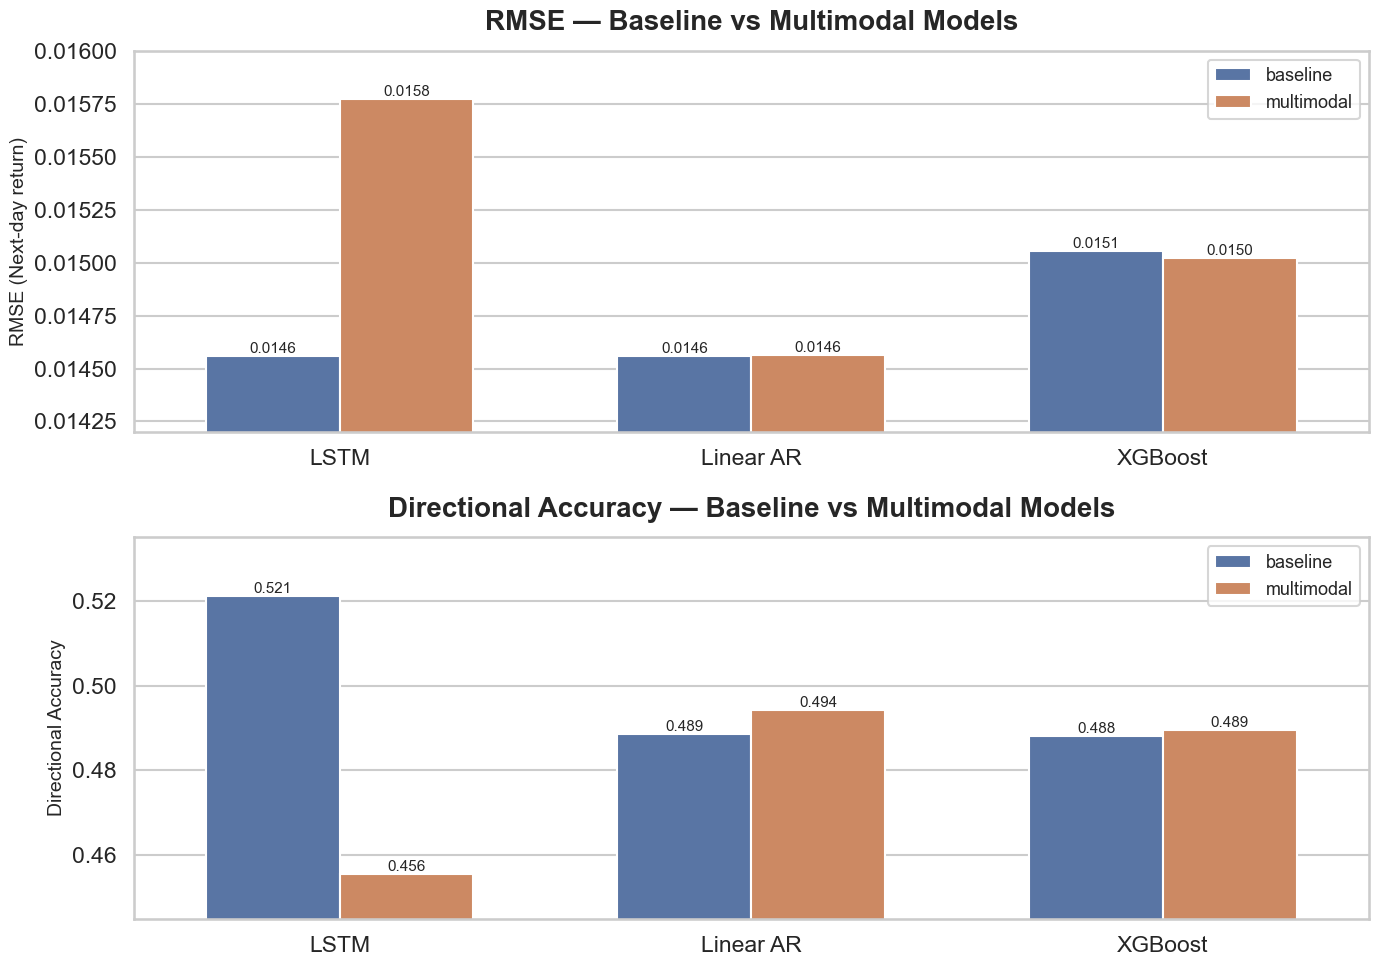

<Figure size 640x480 with 0 Axes>

In [25]:
palette = ["#4C72B0", "#DD8452"]   # blue, orange

plt.figure(figsize=(14, 10))

# Helper to be compatible with different seaborn versions
def barplot_no_errorbars(data, x, y, hue, palette, width):
    try:
        ax = sns.barplot(
            data=data, x=x, y=y, hue=hue,
            palette=palette, width=width,
            errorbar=None          # seaborn >= 0.12
        )
    except TypeError:
        ax = sns.barplot(
            data=data, x=x, y=y, hue=hue,
            palette=palette, width=width,
            ci=None                # seaborn < 0.12
        )
    return ax

# ------------------------------------------------------
# 1) RMSE Plot
# ------------------------------------------------------
plt.subplot(2, 1, 1)
ax1 = barplot_no_errorbars(
    data=rmse_plot,
    x="family", y="RMSE",
    hue="type", palette=palette, width=0.65
)

plt.title("RMSE — Baseline vs Multimodal Models", fontsize=20, weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("RMSE (Next-day return)", fontsize=14)

for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(
        f"{height:.4f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom",
        fontsize=11
    )

plt.legend(title="", fontsize=13, loc="upper right")
plt.ylim(0.0142, 0.0160)

# ------------------------------------------------------
# 2) Directional Accuracy Plot
# ------------------------------------------------------
plt.subplot(2, 1, 2)
ax2 = barplot_no_errorbars(
    data=diracc_plot,
    x="family", y="DirAcc",
    hue="type", palette=palette, width=0.65
)

plt.title("Directional Accuracy — Baseline vs Multimodal Models", fontsize=20, weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Directional Accuracy", fontsize=14)

for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(
        f"{height:.3f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom",
        fontsize=11
    )

plt.legend(title="", fontsize=13, loc="upper right")
plt.ylim(0.445, 0.535)

plt.tight_layout()
plt.show()

# (optional) save
plt.savefig("../../figures/rmse_diracc_comparison.png", dpi=300, bbox_inches="tight")


In [20]:
BASE_DIR

WindowsPath('C:/Users/mkcak/OneDrive - Hochschule Luzern/Modules/master_thesis/multimodal-finance-forecasting/code')